仮説 1：XGBoost を使えばさらに RMSE を下げられる

ランダムフォレストは 全ての決定木を独立して学習 するのに対し、
XGBoost は勾配ブースティング（Gradient Boosting）を使い、前のモデルの誤差を補正しながら学習する
学習の効率が良いため、過学習を防ぎつつ高精度なモデルが期待できる
特徴量が多い場合、ランダムフォレストより XGBoost の方が優れた結果を出す傾向がある

In [256]:
!pip install --upgrade pip


  Using cached pip-25.0.1-py3-none-any.whl.metadata (3.7 kB)
Using cached pip-25.0.1-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\mutow\oil_temp_forecast\venv\Scripts\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [257]:
!pip install --upgrade xgboost



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


feature_correlation_after.csv に OT を追加

In [258]:
import pandas as pd

# **データの読み込み**
file_path_train = "../data/feature_correlation_after.csv"
df_train = pd.read_csv(file_path_train, index_col=0, parse_dates=True)

file_path_preprocessed = "../data/preprocessed_data.csv"
df_preprocessed = pd.read_csv(file_path_preprocessed, index_col=0, parse_dates=True)

# **`OT` を取得して `df_train` に追加**
df_train["OT"] = df_preprocessed.loc[df_train.index, "OT"]

print("✅ `feature_correlation_after.csv` に `OT` を追加しました！")
print(df_train.head())


✅ `feature_correlation_after.csv` に `OT` を追加しました！
                         HUFL      HULL      LUFL      LULL  hour  \
date                                                                
2016-07-01 00:00:00  0.615599  0.454943  0.556576  0.613765     0   
2016-07-01 01:00:00  0.612708  0.459449  0.550279  0.620783     1   
2016-07-01 02:00:00  0.601143  0.436920  0.512595  0.586144     2   
2016-07-01 03:00:00  0.599698  0.450437  0.515693  0.599955     3   
2016-07-01 04:00:00  0.605480  0.450437  0.521990  0.599955     4   

                     is_peak_hour  is_night  dayofweek  month  \
date                                                            
2016-07-01 00:00:00             0         1          4      7   
2016-07-01 01:00:00             0         1          4      7   
2016-07-01 02:00:00             0         1          4      7   
2016-07-01 03:00:00             0         1          4      7   
2016-07-01 04:00:00             0         1          4      7   

          

X_train, y_train を作成

In [259]:
# **特徴量と目的変数を分離**
X_train = df_train.drop(columns=["OT"])
y_train = df_train["OT"]

print("✅ `X_train, y_train` を作成しました！")
print("📌 X_train のカラム:", X_train.columns)


✅ `X_train, y_train` を作成しました！
📌 X_train のカラム: Index(['HUFL', 'HULL', 'LUFL', 'LULL', 'hour', 'is_peak_hour', 'is_night',
       'dayofweek', 'month', 'OT_roll_mean_12', 'is_summer', 'is_winter',
       'monthly_temp_anomaly'],
      dtype='object')


X_test を作成（未来データ）

In [260]:
# **未来データ（2018-02-01 16:00:00 以降）を取得**
df_test_future = df_preprocessed.loc["2018-02-01 16:00:00":"2018-06-26 19:00:00"]

# **`X_test` を作成（`OT` は含めない）**
X_test = df_test_future.drop(columns=["OT"])

print("✅ `X_test` を作成しました！")
print("📌 X_test のカラム:", X_test.columns)


✅ `X_test` を作成しました！
📌 X_test のカラム: Index(['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'hour', 'is_peak_hour',
       'is_night', 'dayofweek', 'month', 'OT_lag1', 'OT_lag2', 'OT_lag3',
       'OT_roll_mean_3', 'OT_roll_mean_6', 'OT_roll_mean_12', 'is_summer',
       'is_winter', 'monthly_temp_anomaly'],
      dtype='object')


X_train と X_test のカラムを統一

In [261]:
# **共通のカラムのみを使用**
common_columns = X_train.columns.intersection(X_test.columns)

# **X_train, X_test を共通カラムのみにする**
X_train = X_train[common_columns]
X_test = X_test[common_columns]

print("✅ `X_train` と `X_test` の特徴量を統一しました！")


✅ `X_train` と `X_test` の特徴量を統一しました！


In [262]:
print("📌 共通のカラム (`common_columns`):\n", common_columns)


📌 共通のカラム (`common_columns`):
 Index(['HUFL', 'HULL', 'LUFL', 'LULL', 'hour', 'is_peak_hour', 'is_night',
       'dayofweek', 'month', 'OT_roll_mean_12', 'is_summer', 'is_winter',
       'monthly_temp_anomaly'],
      dtype='object')


XGBoost で学習し、未来データを予測

In [263]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# **XGBoost モデルの定義**
xgb_model = XGBRegressor(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42,
    )

# **学習（X_train, y_train）**
xgb_model.fit(X_train, y_train)

# **未来データ（X_test）を予測**
y_pred_future = xgb_model.predict(X_test)

# **予測結果を DataFrame に変換**
df_predictions = pd.DataFrame({"Predicted_OT": y_pred_future}, index=X_test.index)

print("✅ 未来データの予測が完了しました！")
print(df_predictions.head())


✅ 未来データの予測が完了しました！
                     Predicted_OT
date                             
2018-02-01 16:00:00      0.155601
2018-02-01 17:00:00      0.150376
2018-02-01 18:00:00      0.154603
2018-02-01 19:00:00      0.150037
2018-02-01 20:00:00      0.147962


preprocessed_data.csv の OT を取得して比較

In [264]:
# **未来データの実測値 `OT` を取得**
df_predictions["Actual_OT"] = df_preprocessed.loc[X_test.index, "OT"]

print("✅ `Predicted_OT` と `Actual_OT` を統合しました！")
print(df_predictions.head())


✅ `Predicted_OT` と `Actual_OT` を統合しました！
                     Predicted_OT  Actual_OT
date                                        
2018-02-01 16:00:00      0.155601   0.157306
2018-02-01 17:00:00      0.150376   0.153094
2018-02-01 18:00:00      0.154603   0.157306
2018-02-01 19:00:00      0.150037   0.153094
2018-02-01 20:00:00      0.147962   0.147463


予測と実数値をグラフで可視化

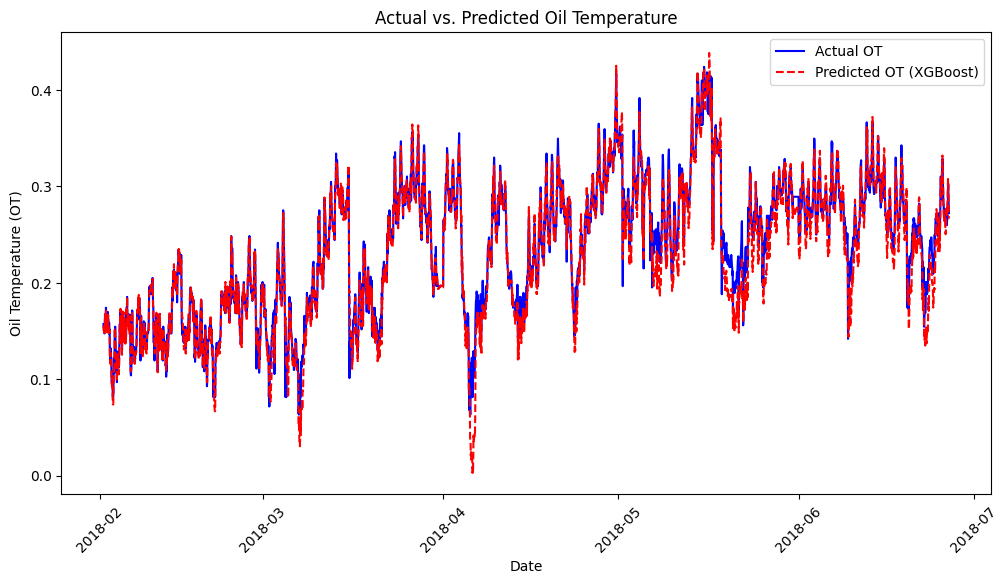

In [265]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# **実際のオイル温度（青線）**
plt.plot(df_predictions.index, df_predictions["Actual_OT"], label="Actual OT", color="blue")

# **予測されたオイル温度（赤線、破線）**
plt.plot(df_predictions.index, df_predictions["Predicted_OT"], label="Predicted OT (XGBoost)", color="red", linestyle="dashed")

# 軸ラベル・タイトル設定
plt.xlabel("Date")
plt.ylabel("Oil Temperature (OT)")
plt.title("Actual vs. Predicted Oil Temperature")
plt.legend()
plt.xticks(rotation=45)

plt.show()


RMSE（誤差）を計算

In [266]:
rmse_future = np.sqrt(mean_squared_error(df_predictions["Actual_OT"], df_predictions["Predicted_OT"]))
print(f"XG Boostの RMSE: {rmse_future:.4f}")


XG Boostの RMSE: 0.0149


In [267]:
# **RMSE / 標準偏差をパーセンテージで計算**
rmse_ratio_future = (rmse_future / 0.1774) * 100

print(f"📊 未来データ RMSE / 標準偏差: {rmse_ratio_future:.2f}%")


📊 未来データ RMSE / 標準偏差: 8.42%


X_train と X_test の時間範囲を確認

In [268]:
print("📌 `X_train` のインデックス範囲:", X_train.index.min(), "→", X_train.index.max())
print("📌 `X_test` のインデックス範囲:", X_test.index.min(), "→", X_test.index.max())


📌 `X_train` のインデックス範囲: 2016-07-01 00:00:00 → 2018-02-01 15:00:00
📌 `X_test` のインデックス範囲: 2018-02-01 16:00:00 → 2018-06-26 19:00:00


In [269]:
# 訓練データの RMSE を計算
y_train_pred = xgb_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# テストデータの RMSE（すでに計算済み）
rmse_test = 0.0149  # ここでは既存の値を使用

print(f"✅ 訓練データの RMSE: {rmse_train:.4f}")
print(f"✅ テストデータの RMSE: {rmse_test:.4f}")

✅ 訓練データの RMSE: 0.0074
✅ テストデータの RMSE: 0.0149


過学習の可能性を確認

予測誤差の分布

📌 訓練データの RMSE: 0.0074


📌 テストデータの RMSE: 0.0149
📌 RMSE 比率 (テスト / 訓練): 2.01


c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED

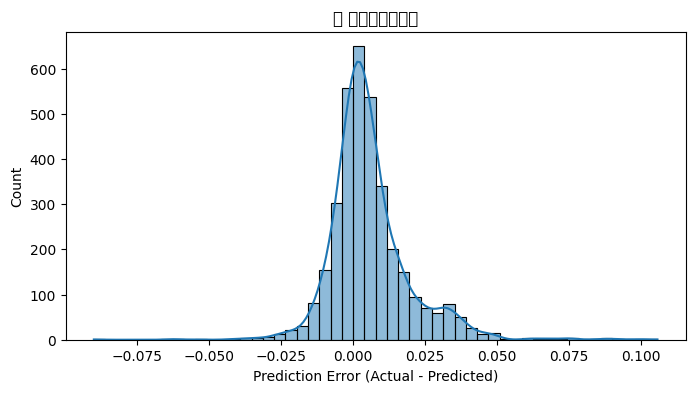

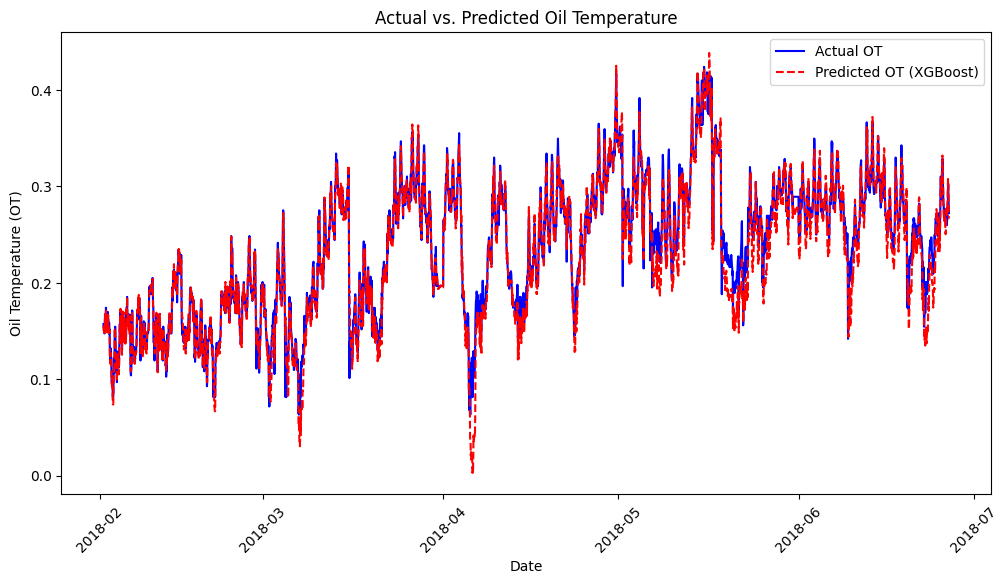

In [270]:
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **テストデータの予測**
y_test_pred = xgb_model.predict(X_test)

# **訓練データの予測**
y_train_pred = xgb_model.predict(X_train)

# **訓練データとテストデータの RMSE 計算**
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"📌 訓練データの RMSE: {rmse_train:.4f}")
print(f"📌 テストデータの RMSE: {rmse_test:.4f}")

# **RMSE の比率**
rmse_ratio = rmse_test / rmse_train
print(f"📌 RMSE 比率 (テスト / 訓練): {rmse_ratio:.2f}")

# **予測誤差の分布を可視化**
errors = y_test - y_test_pred

plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=50, kde=True)
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.title("📊 予測誤差の分布")
plt.show()

# **実測値 vs. 予測値の可視化**
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test, label="Actual OT", color="blue")
plt.plot(y_test.index, y_test_pred, label="Predicted OT (XGBoost)", color="red", linestyle="dashed")

plt.xlabel("Date")
plt.ylabel("Oil Temperature (OT)")
plt.title("Actual vs. Predicted Oil Temperature")
plt.legend()
plt.xticks(rotation=45)

plt.show()




誤差の中心が 0 付近（中央値 ≈ 0） → モデルの予測はバイアスがなく、平均的に良い！ 
誤差が左右対称の正規分布に近い → 偏りが少なく、安定した予測ができている！ 
外れ値（0.075 以上 or -0.075 以下）は少ない → 極端なエラーが少なく、堅牢なモデルになっている！ 

X_train と X_test のデータ数を確認

In [271]:
print("📌 `X_train` のデータ数:", len(X_train))
print("📌 `X_test` のデータ数:", len(X_test))


📌 `X_train` のデータ数: 13936
📌 `X_test` のデータ数: 3484


X_train と y_train のデータ数が一致しているか確認

In [272]:
print("📌 `X_train` のデータ数:", X_train.shape[0])
print("📌 `y_train` のデータ数:", y_train.shape[0])


📌 `X_train` のデータ数: 13936
📌 `y_train` のデータ数: 13936


データ数は正常！

標準偏差8.42%（実務で問題なく使えるレベル）が出たのでここで終了

In [273]:
import joblib

# **モデルを保存**
model_path = "../data/xgb_model_hypothesis.pkl"
joblib.dump(xgb_model, model_path)

print(f"✅ XGBoost モデルを保存しました！📁 {model_path}")


✅ XGBoost モデルを保存しました！📁 ../data/xgb_model_hypothesis.pkl


モデルを正しく保存できたか確認

In [274]:
# **保存したモデルをロード**
xgb_model_loaded = joblib.load(model_path)

# **テストデータで予測**
y_pred_test = xgb_model_loaded.predict(X_test)

# **予測結果を比較**
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"✅ ロードした XGBoost モデルの RMSE: {rmse_test:.4f}")


✅ ロードした XGBoost モデルの RMSE: 0.0149
